In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("samplesuperstore.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12-06-2017,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
df.shape

(9800, 18)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [4]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


The dataset contains 9,800 records.
The average sales per order are approximately 230.77.
The minimum sales value is 0.44.
The maximum sales value is 22,638.48, indicating some very large orders.
The sales data is highly spread out (standard deviation = 626.65), suggesting significant variation among orders.
The Postal Code column contains 11 missing values.

In [5]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

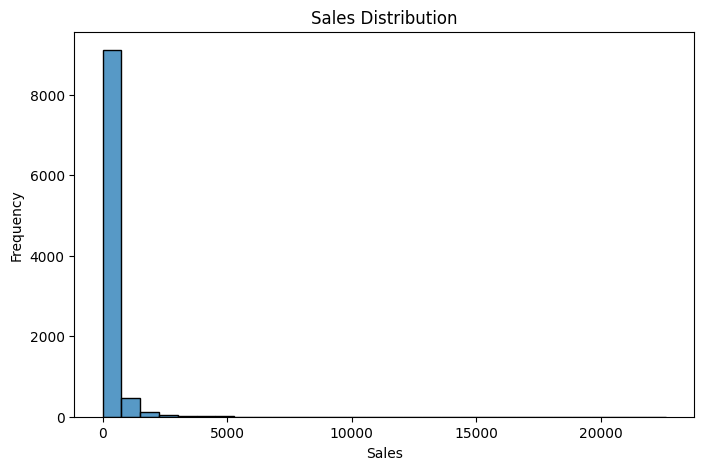

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=30)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.savefig('sales_distribution.png',dpi=300,bbox_inches='tight')
plt.show()

Most sales are below ₹500 (or the dataset's currency units).
A few orders have sales above 5,000 and even above 20,000.
These large values stretch the x-axis, making the smaller values appear compressed.

In [8]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

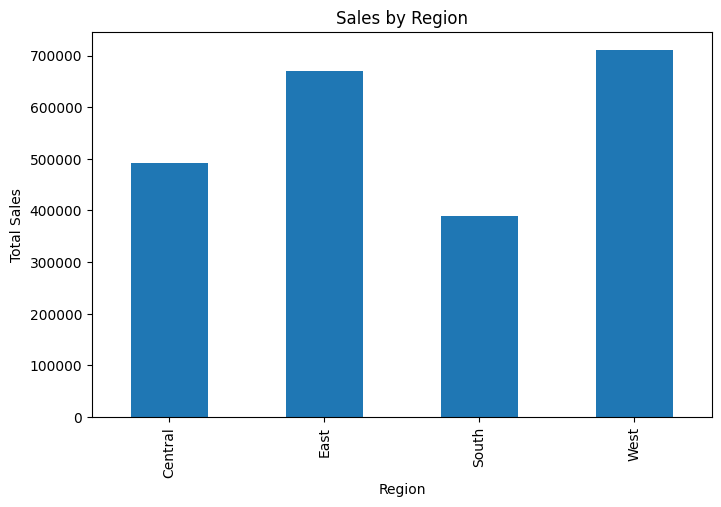

In [11]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar', figsize=(8,5))
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.savefig('region_sales.png', dpi=300, bbox_inches='tight')
plt.show()

The West region generated the highest sales, followed closely by the East region. The South region recorded the lowest sales among all regions. This indicates that the company's strongest market presence is in the West and East regions.
Key Insight
Highest Sales: West
Second Highest: East
Third: Central
Lowest: South

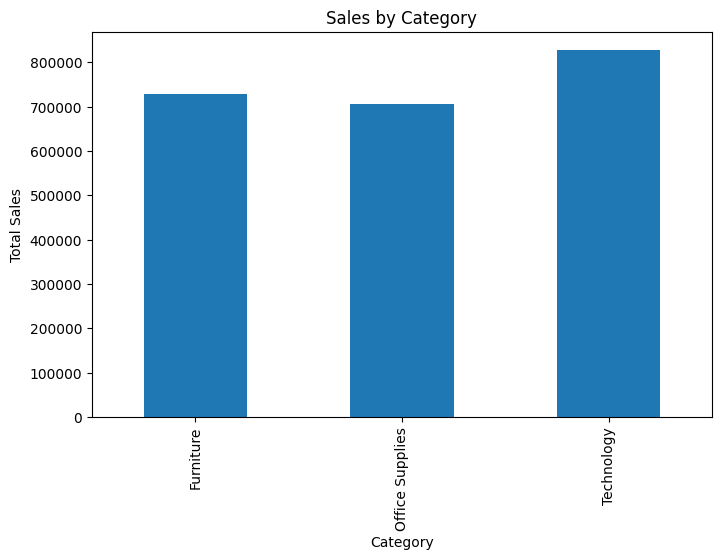

In [12]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar', figsize=(8,5))
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.savefig('category_sales.png', dpi=300, bbox_inches='tight')
plt.show()

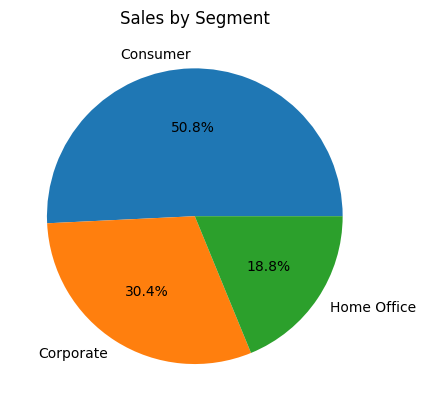

In [13]:
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales by Segment')
plt.ylabel('')

plt.savefig('sales_by_segment.png', dpi=300, bbox_inches='tight')
plt.show()

Consumer segment contributed the highest share of sales, followed by Corporate and Home Office segments.

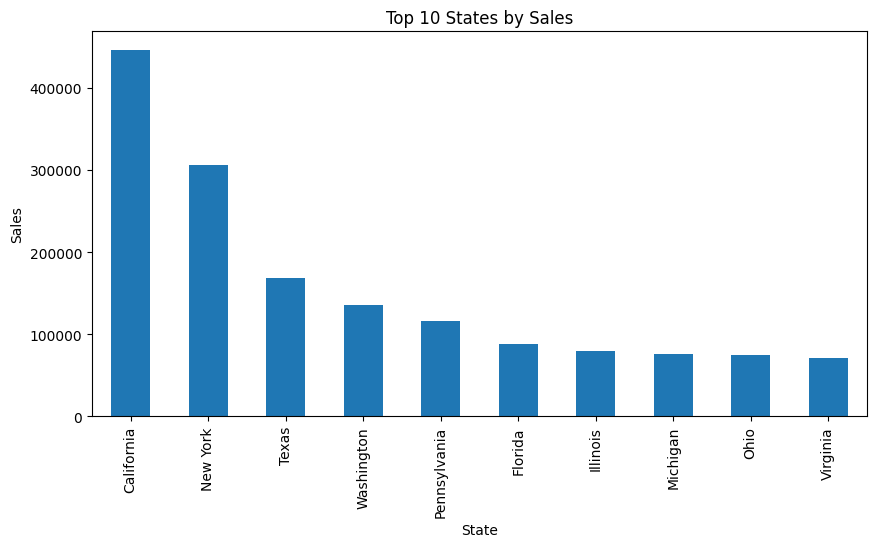

In [15]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar')
plt.title('Top 10 States by Sales')
plt.xlabel('State')
plt.ylabel('Sales')
plt.savefig('top_10_states_sales.png', dpi=300, bbox_inches='tight')
plt.show()

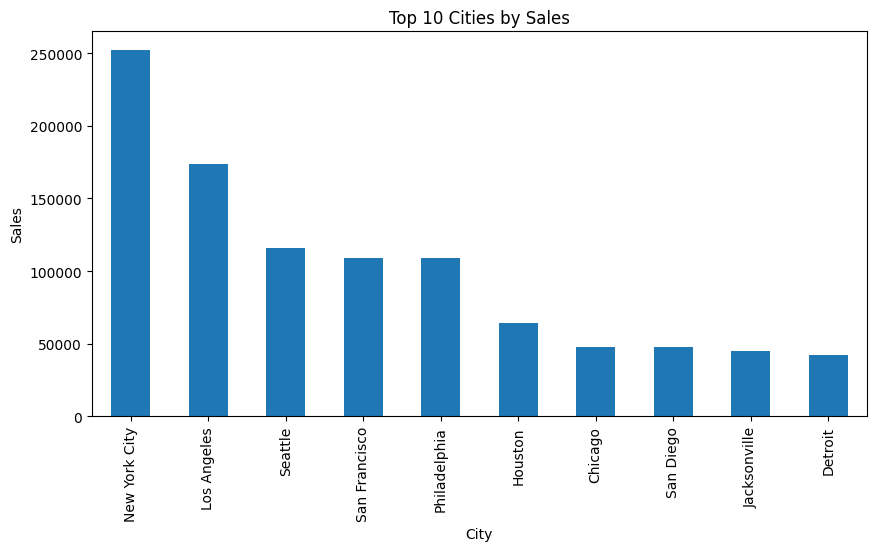

In [17]:
top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_cities.plot(kind='bar')

plt.title('Top 10 Cities by Sales')
plt.xlabel('City')
plt.ylabel('Sales')

plt.savefig('top_10_cities_sales.png', dpi=300, bbox_inches='tight')

plt.show()

A few cities contribute a major portion of total sales. These cities represent the company's strongest markets.

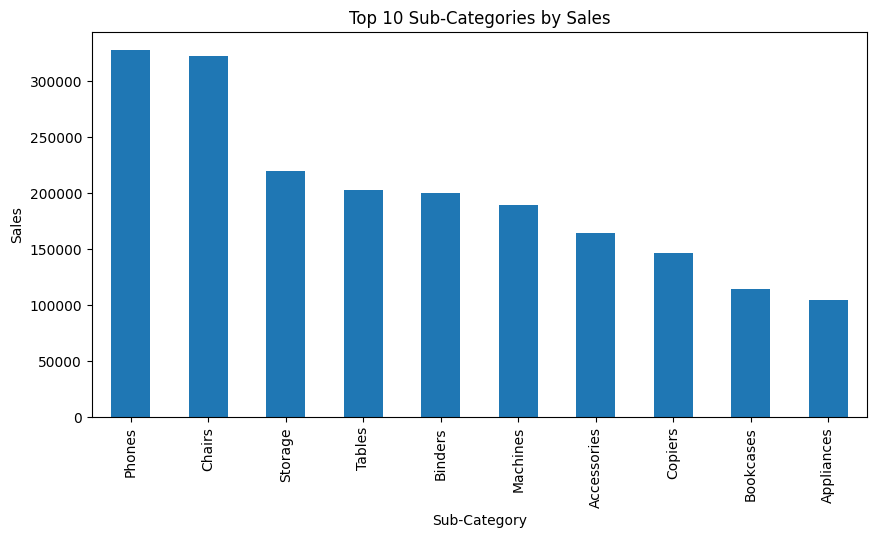

In [18]:
top_subcat = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_subcat.plot(kind='bar')

plt.title('Top 10 Sub-Categories by Sales')
plt.xlabel('Sub-Category')
plt.ylabel('Sales')

plt.savefig('top_10_subcategories.png', dpi=300, bbox_inches='tight')

plt.show()

Certain product sub-categories generate significantly higher revenue than others.

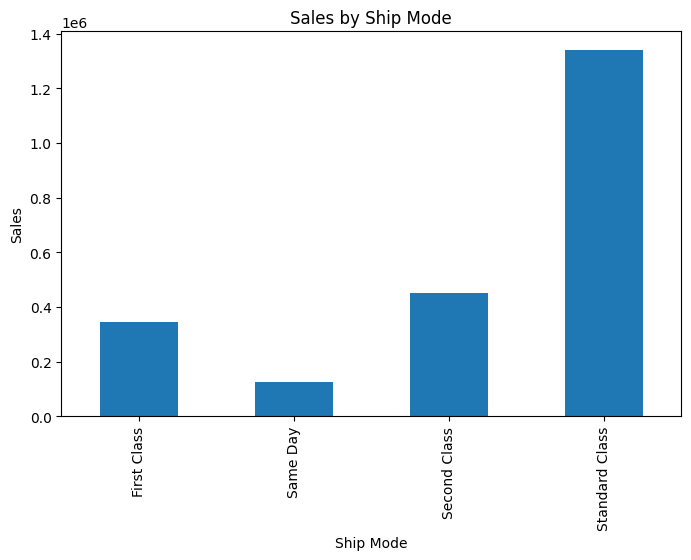

In [19]:
ship_sales = df.groupby('Ship Mode')['Sales'].sum()

plt.figure(figsize=(8,5))
ship_sales.plot(kind='bar')

plt.title('Sales by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Sales')

plt.savefig('sales_by_ship_mode.png', dpi=300, bbox_inches='tight')

plt.show()

Standard Class contributes the highest sales among all shipping modes.

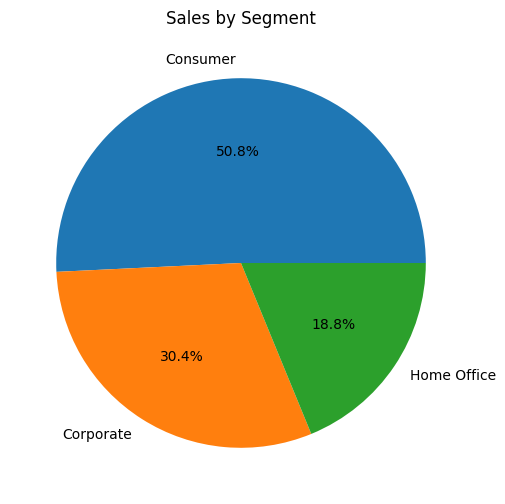

In [20]:
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(6,6))
segment_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title('Sales by Segment')
plt.ylabel('')

plt.savefig('sales_by_segment.png', dpi=300, bbox_inches='tight')

plt.show()

The Consumer segment contributes the largest share of sales, followed by Corporate and Home Office.